In [3]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score


In [6]:
#Load Dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print("Dataset Shape:",df.shape)
print(df.head())

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [88]:
#split
X = df.drop("Price",axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state=42)

print(X_train.shape, X_test.shape)

(14448, 8) (6192, 8)


In [89]:
#Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:5])
print("\n\n",X_test[:5])

[[ 0.13350629  0.50935748  0.18106017 -0.27384968 -0.18411678 -0.01082519
  -0.80568191  0.78093406]
 [-0.53221805 -0.67987313 -0.42262953 -0.04786832 -0.37619075 -0.08931585
  -1.33947268  1.24526986]
 [ 0.1709897  -0.36274497  0.07312833 -0.24260044 -0.61124018 -0.04480037
  -0.49664515 -0.27755183]
 [-0.40291602 -1.15556537  0.17584811 -0.00855953 -0.98749467 -0.07522954
   1.69002403 -0.70693761]
 [-0.2992854   1.85715216 -0.25959807 -0.07099289  0.08601465 -0.06635658
   0.99235014 -1.43090202]]


 [[-1.1526893  -0.28346293 -0.50781822 -0.16927816 -0.03151006  0.06127763
   0.19166399  0.28664112]
 [-0.70640568  0.11294728 -0.16252032  0.21332681  0.1202196  -0.03551561
  -0.23911452  0.06196251]
 [-0.20830675  1.85715216 -0.59546738  0.19630786 -0.10342817 -0.14215427
   1.00639726 -1.42590916]
 [ 0.97683062 -0.91771925  0.29570668 -0.17393109  0.24300661  0.02628324
  -0.64179878  0.43143401]
 [-0.07973969  0.43007544  0.02236249 -0.15642121 -0.32005954 -0.05136838
   0.453877  

In [90]:
#build model

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu',input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1)

]

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [91]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
#Train Model
history = model.fit(X_train,y_train,epochs=100,batch_size=128,validation_split=0.1,verbose=1)


Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.7524 - mae: 1.2285 - val_loss: 0.6395 - val_mae: 0.5713
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5986 - mae: 0.5554 - val_loss: 0.4522 - val_mae: 0.4707
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4279 - mae: 0.4675 - val_loss: 0.4111 - val_mae: 0.4499
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3764 - mae: 0.4371 - val_loss: 0.3895 - val_mae: 0.4460
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3792 - mae: 0.4334 - val_loss: 0.3733 - val_mae: 0.4305
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3519 - mae: 0.4212 - val_loss: 0.3586 - val_mae: 0.4212
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3496 - mae: 0.4179 - val_loss: 0.3418 - val_mae: 0.4107
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3185 - mae: 0.3944 - val_loss: 0.3315 - val_mae: 0.4106
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [93]:
#Evaluate Models
loss, mae = model.evaluate(X_test,y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2 Score: {r2}")

194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2649 - mae: 0.3481
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Absolute Error: 0.34671255946159363
Root Mean Squared Error: 0.5133538314549133
R2 Score: 0.7992197307338877


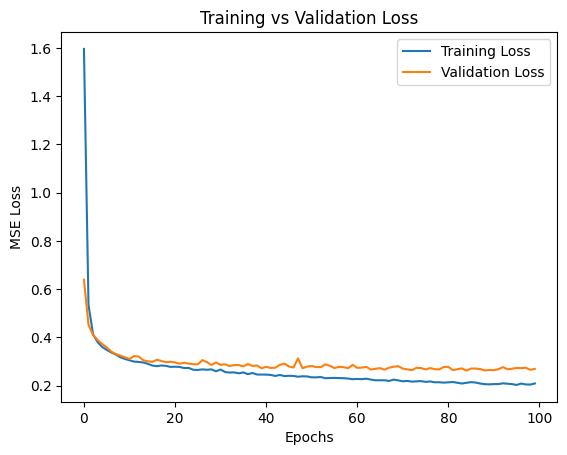

In [94]:
#plot training curve
plt.figure()
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

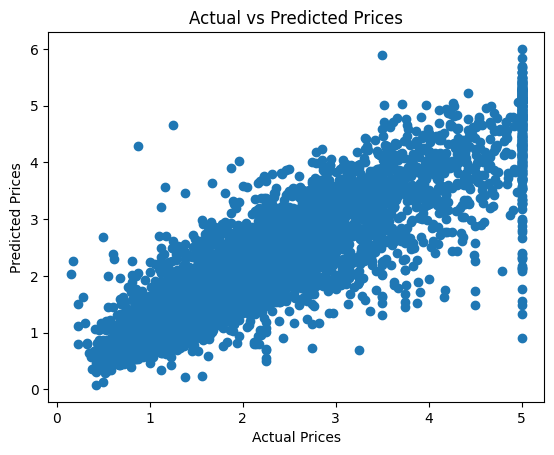

In [95]:
#actual vs predicted plot
plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()
